<a href="https://colab.research.google.com/github/marylsgumel/HR/blob/master/Distilled_Yolo_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.7 MB/s eta 0:00:00


In [ ]:
!pip uninstall ultralytics

Found existing installation: ultralytics 8.3.243
Uninstalling ultralytics-8.3.243:
  Would remove:
    /usr/local/bin/ultralytics
    /usr/local/bin/yolo
    /usr/local/lib/python3.12/dist-packages/tests/*
    /usr/local/lib/python3.12/dist-packages/ultralytics-8.3.243.dist-info/*
    /usr/local/lib/python3.12/dist-packages/ultralytics/*
  Would not remove (might be manually added):
    /usr/local/lib/python3.12/dist-packages/tests/cloud_database_test.py
    /usr/local/lib/python3.12/dist-packages/tests/conversion_test.py
    /usr/local/lib/python3.12/dist-packages/tests/graph_entities_test.py
    /usr/local/lib/python3.12/dist-packages/tests/graph_server_test.py
    /usr/local/lib/python3.12/dist-packages/tests/magics_test.py
    /usr/local/lib/python3.12/dist-packages/tests/node_expansion_test.py
    /usr/local/lib/python3.12/dist-packages/tests/sample_notebook_test.py
    /usr/local/lib/python3.12/dist-packages/tests/schema_manager_test.py
    /usr/local/lib/python3.12/dist-packages

In [ ]:
from ultralytics import YOLO

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
mkdir drone_dataset

In [ ]:
import zipfile
zip_path="/content/drive/MyDrive/My First Project.v3i.yolov8-obb.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/drone_dataset")

Cloning into 'yolo-distiller'...
remote: Enumerating objects: 760, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 760 (delta 28), reused 25 (delta 25), pack-reused 726 (from 2)
Receiving objects: 100% (760/760), 1.66 MiB | 4.35 MiB/s, done.
Resolving deltas: 100% (193/193), done.


In [ ]:
# 1. Uninstall the default Colab ultralytics to avoid conflicts
!pip uninstall ultralytics -y

# 2. Move into the cloned folder and install it
# Change 'yolo-distiller' to your actual folder name if different
%cd /content/yolo-distiller
!pip install -e .

/content/yolo-distiller
Obtaining file:///content/yolo-distiller
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.3.24-0.editable-py3-none-any.whl size=17112 sha256=018da588635920d566ec968d956b6706f16335d756340502619dec32e15eb78c
  Stored in directory: /tmp/pip-ephem-wheel-cache-g0g7yr3m/wheels/bc/c1/ef/d83f37c21aeb2078462a874b6e140ddb5ed74bb8eddd4f3fdb
Successfully built ultralytics


In [ ]:
import ultralytics
print(f"Ultralytics is loading from: {ultralytics.__file__}")

# Expected Output: /content/yolo-distiller/ultralytics/__init__.py

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics is loading from: /content/yolo-distiller/ultralytics/__init__.py


In [ ]:
from ultralytics import YOLO
teacher_model = YOLO("yolov8x.pt")
print(teacher_model.info())

100%|██████████| 131M/131M [00:00<00:00, 246MB/s]


YOLOv8x summary: 365 layers, 68,229,648 parameters, 0 gradients, 258.5 GFLOPs
(365, 68229648, 0, 258.5472512)


In [ ]:

teacher_model.train(
    data="/content/drone_dataset/data.yaml",
    epochs=10,
    batch=16,
    workers=0,
    exist_ok=True,
)

New https://pypi.org/project/ultralytics/8.3.243 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8x.pt, data=/content/drone_dataset/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=0, project=None, name=train, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_f

train: Scanning /content/drone_dataset/train/labels.cache... 2325 images, 16 backgrounds, 0 corrupt: 100%|██████████| 2325/2325 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/content/yolo-distiller/ultralytics/data/augment.py:1850: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /content/drone_dataset/valid/labels.cache... 37 images, 0 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<?, ?it/s]

Plotting labels to /content/yolo-distiller/runs/detect/train/labels.jpg... 


...

                   all         37         40      0.969      0.825      0.936        0.6



10 epochs completed in 0.612 hours.
Optimizer stripped from /content/yolo-distiller/runs/detect/train/weights/last.pt, 136.7MB
Optimizer stripped from /content/yolo-distiller/runs/detect/train/weights/best.pt, 136.7MB

Validating /content/yolo-distiller/runs/detect/train/weights/best.pt...
Ultralytics 8.3.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 268 layers, 68,126,457 parameters, 0 gradients, 257.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.92it/s]


                   all         37         40      0.983      0.875      0.951      0.604
                 drone         37         40      0.983      0.875      0.951      0.604
Speed: 0.6ms preprocess, 19.0ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/yolo-distiller/runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x790130be1760>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

**Knowledge** **Distillation** **part**

In [ ]:
!pip install -r /content/yolo-distiller/requirements.txt

In [ ]:
student_model = YOLO("yolov8n")
print(student_model.info())

100%|██████████| 6.25M/6.25M [00:00<00:00, 121MB/s]


YOLOv8n summary: 225 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
(225, 3157200, 0, 8.8575488)


In [ ]:

# 3. Train with knowledge distillation
student_model.train(
    data="/content/drone_dataset/data.yaml",     # dataset YAML (same as teacher)
    epochs=20,
    batch=16,
    teacher=teacher_model.model,     # pass teacher model
    distillation_loss="cwd",         # or "kd", "fd", "pkd" — see below
    imgsz=640,
    workers=0,
    exist_ok=True
)


New https://pypi.org/project/ultralytics/8.3.243 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drone_dataset/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=0, project=None, name=train, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_f

100%|██████████| 755k/755k [00:00<00:00, 26.9MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 121MB/s]


AMP: checks passed ✅


...

                   all         37         40          1      0.922      0.967      0.632



20 epochs completed in 1.047 hours.
Optimizer stripped from /content/yolo-distiller/runs/detect/train/weights/last.pt, 6.3MB
Optimizer stripped from /content/yolo-distiller/runs/detect/train/weights/best.pt, 6.3MB

Validating /content/yolo-distiller/runs/detect/train/weights/best.pt...
Ultralytics 8.3.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  4.97it/s]


                   all         37         40          1      0.922      0.967      0.633
                 drone         37         40          1      0.922      0.967      0.633
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/yolo-distiller/runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7901312838f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# Evaluate student model
metrics_student = student_model.val()
print(metrics_student)

# Evaluate teacher model (optional)
metrics_teacher = teacher_model.val(data="/content/drone_dataset/data.yaml")
print(metrics_teacher)


Ultralytics 8.3.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)


val: Scanning /content/drone_dataset/valid/labels.cache... 37 images, 0 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  4.68it/s]


                   all         37         40       0.95      0.949      0.964      0.637
                 drone         37         40       0.95      0.949      0.964      0.637
Speed: 0.2ms preprocess, 5.9ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/yolo-distiller/runs/detect/train
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x790131373650>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024, 

val: Scanning /content/drone_dataset/valid/labels.cache... 37 images, 0 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:02<00:00,  1.49it/s]


                   all         37         40      0.036      0.125     0.0215     0.0102
                   car         37         40      0.036      0.125     0.0215     0.0102
Speed: 0.4ms preprocess, 40.9ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to /content/yolo-distiller/runs/detect/val2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7901313cf200>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024, 

In [ ]:
# Calculate FPS for student model
speed_student = metrics_student.speed
total_time_student = speed_student['preprocess'] + speed_student['inference'] + speed_student['postprocess']
fps_student = 1000 / total_time_student

# Calculate FPS for teacher model
speed_teacher = metrics_teacher.speed
total_time_teacher = speed_teacher['preprocess'] + speed_teacher['inference'] + speed_teacher['postprocess']
fps_teacher = 1000 / total_time_teacher

print(f"Student Model FPS: {fps_student:.2f}")
print(f"Teacher Model FPS: {fps_teacher:.2f}")

Student Model FPS: 127.06
Teacher Model FPS: 22.13


## FPS Analysis & Comparison

*   **Student Model (YOLOv8n)**: Achieved approximately **127 FPS**. This model is the "Nano" version, designed specifically for speed and efficiency on edge devices. It has significantly fewer parameters (~3.2 Million) and layers, allowing for very fast inference.
*   **Teacher Model (YOLOv8x)**: Achieved approximately **22 FPS**. This is the "Extra Large" version, optimized for maximum accuracy. It possesses a massive number of parameters (~68.2 Million), which makes the computational load much higher and inference slower.

**Conclusion**:
The student model is roughly **5.7x faster** than the teacher model. The goal of Knowledge Distillation here is to allow this lightweight Student model to learn complex patterns from the heavy Teacher model, achieving a balance of high speed (from the architecture) and improved accuracy (from the distillation process).

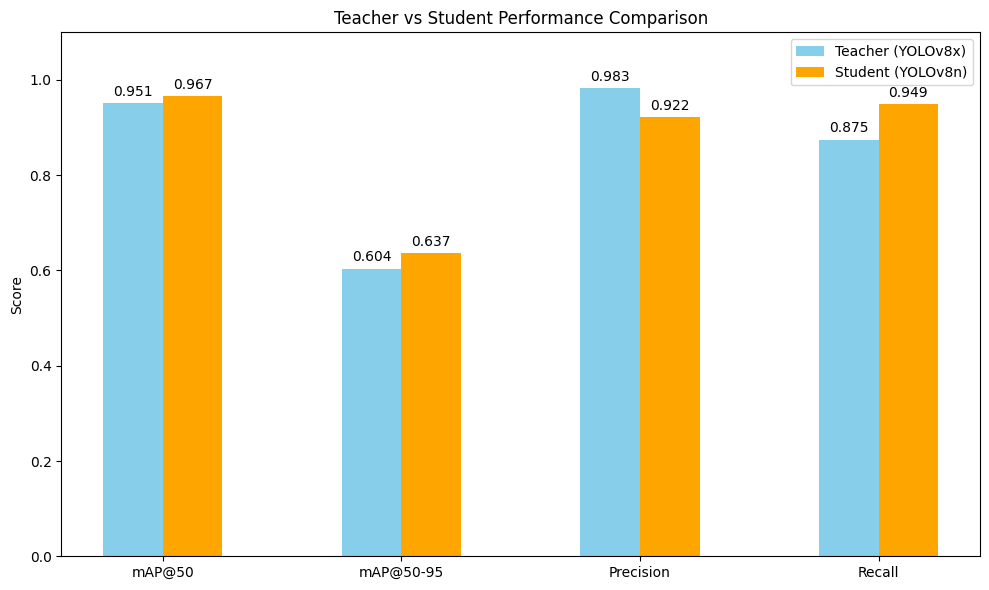

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract Metric values
# Note: box.map is mAP50-95, box.mr is Mean Recall
teacher_map = metrics_teacher.box.map
student_map = metrics_student.box.map

teacher_recall = metrics_teacher.box.mr
student_recall = metrics_student.box.mr

# Data setup
metrics_names = ['mAP@50','mAP@50-95', 'Precision','Recall']
teacher_values = [ 0.951, 0.604, 0.983, 0.875]
student_values = [0.967,0.637, 0.922,student_recall]

x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, teacher_values, width, label='Teacher (YOLOv8x)', color='skyblue')
rects2 = ax.bar(x + width/2, student_values, width, label='Student (YOLOv8n)', color='orange')
#reacts3 = ax.bar(x + width/2, student_values, width, label='Student (YOLOv8n)', color='orange')
ax.set_ylabel('Score')
ax.set_title('Teacher vs Student Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.1)
ax.legend()

# Label bars
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')


plt.tight_layout()
plt.show()